## Nome: Gabriel Faria Monteiro
## Matrícula: 757
---

# Atividade – Interpolação Polinomial

## Breve Explicação
A **interpolação polinomial** é um método numérico fundamental utilizado quando temos um conjunto de pontos conhecidos $(x_i, f(x_i))$ — normalmente obtidos por meio de resultados experimentais, tabelas ou medições de laboratório — e precisamos aproximar essa função desconhecida $f(x)$ por uma função polinomial $p_n(x)$ mais simples de manipular [cite: 1].

A condição básica da interpolação é que o polinômio $p_n(x)$ deve satisfazer a propriedade de passar exatamente por todos os pontos dados, ou seja:
$$p_n(x_i) = f(x_i), \quad para \ i = 0, 1, 2, ..., n$$

Conforme visto em aula, podemos determinar os coeficientes do polinômio interpolador resolvendo um **sistema de equações lineares** ou utilizando formulações específicas como o **Polinômio Interpolador de Lagrange**.

## Funções Auxiliares

In [10]:
# Importando bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Função de Apoio para Interpolação de Lagrange
def interpolacao_lagrange(x_pontos, y_pontos, x_val):
    """
    Calcula o valor do polinômio interpolador de Lagrange no ponto x_val.
    x_pontos: array com os valores de x conhecidos
    y_pontos: array com os valores de y conhecidos
    x_val: ponto onde se deseja estimar o valor
    """
    n = len(x_pontos)
    soma = 0.0
    for i in range(n):
        termo = y_pontos[i]
        for j in range(n):
            if j != i:
                termo = termo * (x_val - x_pontos[j]) / (x_pontos[i] - x_pontos[j])
        soma += termo
    return soma

---
# Parte Prática

## Contexto 1 – Desempenho de Robôs na FETIN
Durante os testes preparatórios para a **FETIN (Feira Tecnológica do Inatel)**, uma equipe de engenharia coletou dados do torque aplicado em um motor de tração de um robô autônomo em função da velocidade angular de teste.

Os dados medidos em laboratório foram organizados na tabela abaixo:

| Velocidade Angular (rad/s) | 1.0 | 2.0 | 3.0 |
|----------------------------|-----|-----|-----|
| Torque Medido (N.m)        | 2.5 | 6.0 | 11.5|

### Questão 1 – Sistema de Equações Lineares
1. Determine analiticamente ou via código o polinômio interpolador de 2º grau $p(x) = a_0 + a_1x + a_2x^2$ que passa exatamente pelos 3 pontos da tabela da FETIN, montando o sistema linear correspondente.

In [12]:
# Resolva a Questão 1 aqui (Monte o sistema linear ou utilize np.linalg.solve para encontrar a0, a1 e a2)
x_fetin = np.array([1.0, 2.0, 3.0])
y_fetin = np.array([2.5, 6.0, 11.5])

# Dica: Matriz de Vandermonde ou coeficientes via np.polyfit com grau 2 (que gera a interpolação exata para 3 pontos)
A = np.vander(x_fetin, N=3, increasing=True)
print('Matriz A:')
print(A)

# Resolução do sistema A @ [a0, a1, a2] = y_fetin
coef_fetin = np.linalg.solve(A, y_fetin)
a0, a1, a2 = coef_fetin

print(f'\nPolinômio interpolador:')
print(f'p(x) = {a0:.4f} + {a1:.4f}x + {a2:.4f}x^2')


Matriz A:
[[1. 1. 1.]
 [1. 2. 4.]
 [1. 3. 9.]]

Polinômio interpolador:
p(x) = 1.0000 + 0.5000x + 1.0000x^2


2. Utilizando o polinômio encontrado, calcule uma estimativa para o torque do robô quando a velocidade angular for de $x = 2.5 \text{ rad/s}$.

In [13]:
# Calcule a estimativa para x = 2.5 aqui
x_estimar = 2.5
torque_estimado = a0 + a1 * x_estimar + a2 * x_estimar**2
print(f'Estimativa de torque para v = {x_estimar} rad/s: {torque_estimado:.4f} N.m')


Estimativa de torque para v = 2.5 rad/s: 8.5000 N.m


## Contexto 2 – Hackathon Inatel & Coneti
Em uma maratona de programação e inovação (**Hackathon do Inatel**), um grupo de alunos precisa modelar o consumo de banda de uma rede de sensores IoT instalada no campus inteligente. A tabela abaixo relaciona o tempo de operação (em horas) com o tráfego medido de dados (em GB):

| Tempo (h)       | 0   | 1   | 3   |
|-----------------|-----|-----|-----|
| Tráfego (GB)    | 1.2 | 2.5 | 8.1 |

### Questão 2 – Método de Lagrange
1. Implemente ou utilize a função de Lagrange fornecida para encontrar o valor aproximado do tráfego de dados no instante $t = 2.0 \text{ horas}$.

In [14]:
# Resolva a Questão 2 usando o método de Lagrange para t = 2.0
x_hack = np.array([0, 1, 3])
y_hack = np.array([1.2, 2.5, 8.1])

valor_estimado = interpolacao_lagrange(x_hack, y_hack, 2.0)
print(f'Tráfego estimado em t = 2.0h: {valor_estimado:.4f} GB')

# Exemplo de chamada: valor_estimado = interpolacao_lagrange(x_hack, y_hack, 2.0)


Tráfego estimado em t = 2.0h: 4.8000 GB


2. Plote o gráfico comparando os pontos experimentais do Hackathon e a curva do polinômio interpolador gerado no intervalo de $0$ a $3$ horas.

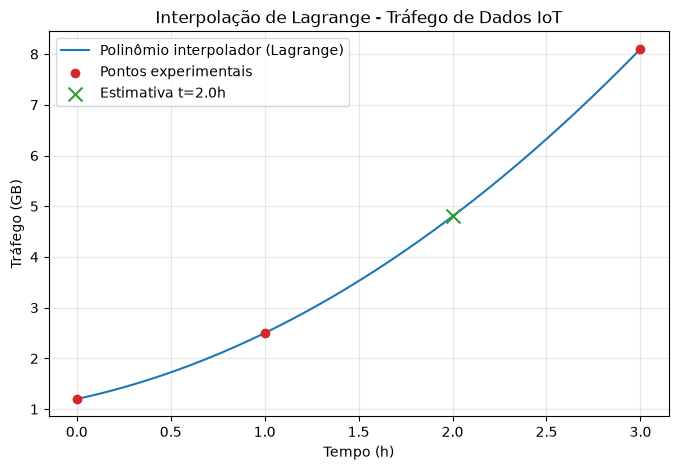

In [15]:
# Plote o gráfico aqui utilizando matplotlib
x_continuo = np.linspace(0, 3, 200)
y_continuo = [interpolacao_lagrange(x_hack, y_hack, xv) for xv in x_continuo]

plt.figure(figsize=(8, 5))
plt.plot(x_continuo, y_continuo, label='Polinômio interpolador (Lagrange)', color='tab:blue')
plt.scatter(x_hack, y_hack, color='tab:red', zorder=5, label='Pontos experimentais')
plt.scatter([2.0], [valor_estimado], color='tab:green', zorder=5, marker='x', s=100, label='Estimativa t=2.0h')

plt.title('Interpolação de Lagrange - Tráfego de Dados IoT')
plt.xlabel('Tempo (h)')
plt.ylabel('Tráfego (GB)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# Parte Teórica

1. Explique com suas próprias palavras qual é a principal diferença conceitual entre **Interpolação Polinomial** e **Ajuste de Curvas por Mínimos Quadrados**.


**Resposta:**

Na interpolação polinomial, o polinômio é obrigado a passar exatamente por todos os pontos conhecidos: p(x_i) = f(x_i) para cada ponto. Já no ajuste por mínimos quadrados, a curva não precisa (e geralmente não consegue) passar exatamente por todos os pontos; em vez disso, busca-se a função que minimiza a soma dos quadrados dos erros (resíduos) entre os valores previstos e os valores medidos. Isso torna o ajuste por mínimos quadrados mais adequado quando os dados têm ruído experimental, pois evita que o modelo tente reproduzir o erro de medição, enquanto a interpolação é mais indicada quando se confia que os pontos são exatos.


2. O que ocorre com o grau do polinômio interpolador à medida que adicionamos mais pontos experimentais ao conjunto de dados? Cite uma possível desvantagem prática disso.


**Resposta:**
Com n+1 pontos distintos, o polinômio interpolador único tem grau no máximo n. Ou seja, o grau cresce junto com o número de pontos adicionados. Uma desvantagem prática importante é o fenômeno de Runge: polinômios de grau elevado tendem a oscilar fortemente entre os pontos conhecidos, principalmente próximo às extremidades do intervalo, produzindo estimativas pouco confiáveis mesmo passando exatamente pelos pontos dados. Por isso, na prática, prefere-se muitas vezes usar interpolação por partes (splines) em vez de um único polinômio de grau muito alto.


3. Qual é a diferença entre **Interpolação** e **Extrapolação**, considerando a posição do ponto que se deseja estimar em relação ao intervalo dos dados conhecidos?



**Resposta:**

A interpolação estima o valor da função em um ponto x que está dentro do intervalo [x_min, x_max] definido pelos dados conhecidos. A extrapolação, por sua vez, estima o valor em um ponto x fora desse intervalo. A extrapolação é geralmente mais arriscada, pois o polinômio foi construído para se ajustar apenas ao comportamento dos dados dentro do intervalo observado, e nada garante que essa mesma tendência se mantenha fora dele — o erro tende a crescer rapidamente quanto mais distante o ponto estiver do intervalo conhecido.
